<div align="center">

# Use of Pit Stop Strategies in Formula 1: 
## Evidence from Race Outcome and Pit Efficiency

### QTM 151 Final Project

#### Group Members: Jiuyi (Joy) Cheng · Sharon Li · Caroline Zu · Alice Li

</div>

## Introduction

Formula 1 (F1) is an international single-seater racing series in which race outcomes are jointly determined by driver skill and team-level decisions, including engineering design, race strategy, and pit crew performance. In every Grand Prix, drivers have to make at least one pit stop to change tires, and teams choose when to stop, how many times to stop, and which tires to use. For our project, we want to explore whether pit stop strategies actually decide race outcomes, and identify drivers that are consistently helped or hurt by them. Using F1 data, we focus on how pit stop duration and timing relate to position changes and points scored. This is worthy to explore because fans often say races are “won in the pits,” but those claims are usually based on a few dramatic moments rather than systematic evidence.

Specifically, we combine the `pit_stops`, `lap_times`, `qualifying`, `races`, `results`, `drivers`, and `constructors` dayaframe to establish a relationship between each driver’s pit stop history to their race outcomes. By splitting our research question into smaller sub-questions, we start by looking at how average pit stop time and number of stops correlate with changes from grid position to final position. Then, we examine which drivers gain or lose the most places after pit stops. On top of this, we then explore the performance of constructors in the pits across seasons (whether or not “teams” behind the driver make a systematic impact). We end by discussing what these patterns suggest about the impact of the pit-stop strategy. 

#### Research Question: How do Formula 1 teams adopt pit stop strategies to impact race outcomes? 

## Data Description

The Formula One dataset contains data on Formula One races since 1950. To answer our questions, we use eight tables from the dataset: `constructors`, `drivers`, `lap_times`, `pit_stops`, `qualifying`, `races`, and `results`. 

- The `constructors` table contains data on the constructors that have competed in Formula One, with 211 rows and 9 columns. Each row represents a different constructor and includes information such as its name, nationality, and other attributes.

- The `drivers` table contains data on drivers who have competed in Formula One, with 854 rows and 9 columns. Each row represents a driver and includes information such as their driver number, forename, and surname.

- The `lap_times` table contains data on drivers’ lap times in races, with 528785 rows and 6 columns. Each row represents a single lap and includes information such as the driver who completed the lap, their position on that lap, and the lap time.

- The `pit_stops` table contains data on the pit stops made during the race, with 9299 rows and 7 columns. Each row represents a single pit stop and includes information such as the driver ID, the number of stops the driver made in that race, and pit stop duration.

- The `qualifying` table contains data on qualifying sessions, with 9395 rows and 9 columns. Each row represents a qualifying round attempt by a driver and includes information such as the driver's qualifying position in that round and Q1, Q2, and Q3 times.

- The `races` table contains data on Formula One races since 1950, with 1079 rows and 18 columns. Each row represents a single race and includes information such as the year of the race and the name of the race.

- The `results` table contains data on Formula One race results, with 25660 rows and 18 columns. Each row represents a driver’s result in a specific race and includes information such as the finishing position of the driver in that race and the points earned by the driver.

In [20]:
# Import relevant libraries
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# Set style
sns.set(style="whitegrid")

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

In [21]:
# Import relevant data files
files = ["constructors", "drivers", "lap_times", "pit_stops", "qualifying", "races", "results"]

# Read data into a dictionary of DataFrames
data = {f: pd.read_csv(f"1-Formula_One/{f}.csv") for f in files}

# Display df dimensions 
for name, df in data.items():
    print(f"{name}: {df.shape}")
    # display(df.head())

constructors: (211, 5)
drivers: (854, 9)
lap_times: (528785, 6)
pit_stops: (9299, 7)
qualifying: (9395, 9)
races: (1079, 18)
results: (25660, 18)


### Data Processing (Merging Procedure)

To create a dataset that is useful for answering our research question, we merge information from multiple tables using shared identifiers such as raceId, driverId, and constructorId. We begin by grouping the `pit_stops` table by each driver in each race and calculating both the total number of pit stops and the average pit stop duration of each driver in each race, so the aggregated table can later be merged with the main dataset using shared identifiers. Then, we define a helper function, `merge_info`, that merges selected columns from one dataframe into another. Next, we use a copy of the `results` table as our foundation since each row represents a single driver’s race outcome in a specific race. We then merge information from other tables into the copied dataframe using the `merge_info` function. We merged the number of pit stops, average pit stop duration for each driver in each race, drivers’ names, constructor names, number of pit count, qualifying grid positions, years of race, rounds, race names, etc. 

In [22]:
# Pit stop aggregation per driver per race
pit_agg = (
    data['pit_stops']
    .groupby(['raceId','driverId'], as_index=False)
    .agg(
        pit_count=('stop','count'),
        avg_pit_duration=('milliseconds','mean')
    )
)

# Define a function to help merging dataframes
def merge_info(df, key, info_df, columns, rename_dict=None):
    temp = info_df[columns]
    if rename_dict:
        temp = temp.rename(columns=rename_dict)
    return df.merge(temp, on=key, how='left')

# Start from results
df = data['results'].copy()

# Merge pit stop info
df = merge_info(
    df, ['raceId','driverId'],
    pit_agg, ['raceId','driverId','pit_count','avg_pit_duration']
)

# Merge driver info
df = merge_info(
    df, 'driverId',
    data['drivers'], ['driverId','forename','surname']
)

# Merge constructor info
df = merge_info(
    df, 'constructorId',
    data['constructors'], ['constructorId','name'], {'name':'constructor'}
)

# Merge qualifying grid (for Q1 regression)
df = merge_info(
    df, ['raceId','driverId'],
    data['qualifying'], ['raceId','driverId','position'], {'position':'grid_position'}
)

# Merge race info 
df = merge_info(
    df, 'raceId',
    data['races'], ['raceId','year','name']
)

# Final cleaned df_formula1
df_formula1 = df[[
    'raceId','year', 'name', 'driverId', 'constructorId', 
    'grid_position','positionOrder',
    'points','laps', 'pit_count','avg_pit_duration'
]].copy()

# Fill missing pit info with 0 (the alternative approach is to drop these rows, while we assume no pit stops = 0)
df_formula1[['pit_count','avg_pit_duration']] = df_formula1[['pit_count','avg_pit_duration']].fillna(0)

# Fill missing grid positions with max + 1 
max_grid = df_formula1['grid_position'].max(skipna=True)
df_formula1['grid_position'] = df_formula1['grid_position'].fillna(max_grid + 1)

display(df_formula1)
print(df_formula1.shape)

,raceId,year,name,driverId,constructorId,grid_position,positionOrder,points,laps,pit_count,avg_pit_duration
0,18,2008,Australian Grand Prix,1,1,1.0,1,10.0,58,0.0,0.000000
1,18,2008,Australian Grand Prix,2,2,5.0,2,8.0,58,0.0,0.000000
2,18,2008,Australian Grand Prix,3,3,7.0,3,6.0,58,0.0,0.000000
3,18,2008,Australian Grand Prix,4,4,12.0,4,5.0,58,0.0,0.000000
4,18,2008,Australian Grand Prix,5,1,3.0,5,4.0,58,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
25655,1086,2022,Hungarian Grand Prix,825,210,13.0,16,0.0,69,3.0,25332.666667
25656,1086,2022,Hungarian Grand Prix,848,3,17.0,17,0.0,69,3.0,25779.333333
25657,1086,2022,Hungarian Grand Prix,849,3,20.0,18,0.0,69,3.0,24364.666667
25658,1086,2022,Hungarian Grand Prix,852,213,16.0,19,0.0,68,3.0,21907.000000


(25660, 11)


After merging, we clean the dataframe to ensure consistency across variables. We first fill in 0 for the missing values in `pit_count` and `avg_pit_duration` to account for drivers who did not make a pit stop. We then replace missing grid positions with one position worse than the maximum existing grid position to ensure that every driver has a valid starting position in the dataset.

### Descriptive Statistics

We will focus on six main columns for our analysis. 
- `grid_position`: the driver’s starting position in the race.
- `positionOrder`: the driver’s finishing position in the race.
- `points`: the total points earned by a driver in the race under the Formula 1scoring system.
- `laps`: the total number of laps completed by a driver in the race.
- `pit_count`: the number of pit stops the driver made during the race.
- `avg_pit_duration`: the average duration of pit stops of each driver in each race. 

In [23]:
# Descriptive statistics
desc_stats = df_formula1[['grid_position', 'positionOrder', 'points', 'laps', 'pit_count', 'avg_pit_duration']].describe()
print("=== Descriptive Statistics ===")
display(desc_stats)

=== Descriptive Statistics ===


,grid_position,positionOrder,points,laps,pit_count,avg_pit_duration
count,25660.000000,25660.000000,25660.000000,25660.000000,25660.000000,2.566000e+04
mean,22.511458,12.892673,1.854523,45.936204,0.362393,1.085270e+04
std,9.352633,7.721729,4.131527,29.867844,0.885140,7.567656e+04
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,15.000000,6.000000,0.000000,22.000000,0.000000,0.000000e+00
50%,29.000000,12.000000,0.000000,52.000000,0.000000,0.000000e+00
75%,29.000000,18.000000,2.000000,66.000000,0.000000,0.000000e+00
max,29.000000,39.000000,50.000000,200.000000,6.000000,3.055732e+06


The descriptive statistics for our main columns highlight important patterns in drivers’ race performance and pit-stop behavior. From the `grid_position` column, we observe that drivers, on average, start from grid position 22.51, with grid position ranging from 1 to 29. The `positionOrder` column shows that drivers finish on average at position 12.89, with finishing positions ranging from 1 to 39. This suggests that drivers typically gain positions during the race. The `points` column reveals that the points earned by each driver in a race are highly skewed, with a median of 0 and a mean of 1.85. This indicates that most drivers do not score points in a given race. 

The `laps` column shows that drivers complete an average of 46 laps, ranging from 0 to 200. The `pit_count` column has a mean of 0.36 and a median of 0, meaning that while some drivers make multiple pit stops, at least half of the drivers make no pit stop at all. Lastly, the `avg_pit_duration` column indicates that across all drivers, including those who did not make a pit stop, the average pit stop duration is about 10.853 seconds. Since this dataset combines pit stop duration accorss years, the technology adopted during pit stop become more efficient to reduce time, justifying the long (but reducing) average time for pit stop duration. 

### Visualization

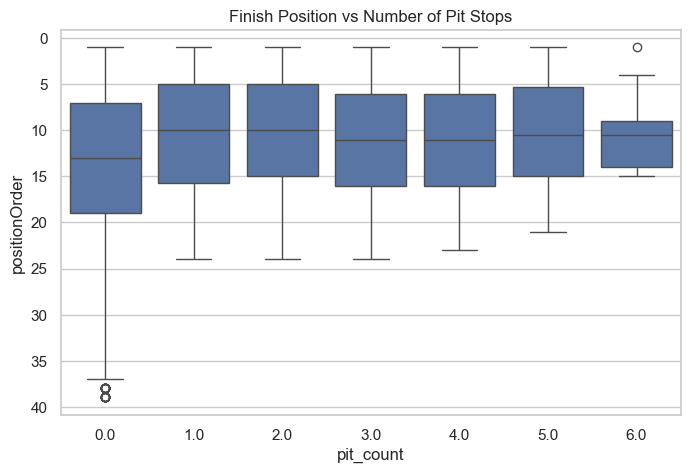

In [24]:
# Pit stops vs finish position
plt.figure(figsize=(8,5))
sns.boxplot(x='pit_count', y='positionOrder', data=df_formula1)
plt.title("Finish Position vs Number of Pit Stops")
plt.gca().invert_yaxis() # 1st place at top
plt.show()

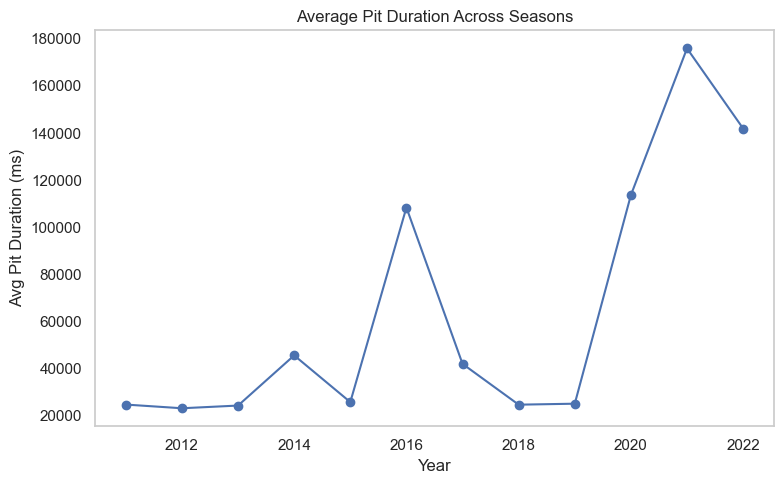

In [25]:
# Average pit duration over years
yearly_pit = df.groupby("year")["avg_pit_duration"].mean().reset_index()

# Plot average pit duration over years
plt.figure(figsize=(8,5))
plt.plot(yearly_pit["year"], yearly_pit["avg_pit_duration"], marker="o")
plt.title("Average Pit Duration Across Seasons")
plt.xlabel("Year")
plt.ylabel("Avg Pit Duration (ms)")
plt.tight_layout()
plt.grid()
plt.show()

### Q1: How much do pit stop strategies change a driver’s expected finishing position?

Our goal is to explore how much pit stop strategies change a driver’s expected finishing position. To do this, we ran an OLS regression to model a driver’s finishing position. We used pit count, average pit stop duration, and grid position as inputs and position order as the outcome of our prediction. We then computed the residuals (computed by predicted - actual) to see which drivers finished better and which finished worse than what was expected from the model. From the regression model we can interpret that starting grid position is a much stronger predictor of finishing position than pit stop count or duration. Moreover,  the overall R² is low, meaning pit variables and grid alone explain only a small share of race outcomes. This shows little evidence that the “pit-stop” myth discussed in the introduction is true.

In [26]:
# Multiple linear regression: positionOrder ~ pit_count + avg_pit_duration + grid_position
model = smf.ols(
    "positionOrder ~ pit_count + avg_pit_duration + grid_position", 
    data=df_formula1
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          positionOrder   R-squared:                       0.067
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     612.4
Date:                Mon, 08 Dec 2025   Prob (F-statistic):               0.00
Time:                        12:10:37   Log-Likelihood:                -87972.
No. Observations:               25660   AIC:                         1.760e+05
Df Residuals:                   25656   BIC:                         1.760e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            8.0217      0.149  

In [27]:
# Analyze residuals to find drivers helped/hurt by pit strategy
df_formula1['predicted'] = model.predict(df_formula1)
df_formula1['residual'] = df_formula1['predicted'] - df_formula1['positionOrder']

# Average residuals per driver
driver_effects = (
    df_formula1.groupby('driverId')['residual'].mean().reset_index()
    .merge(data['drivers'][['driverId','forename','surname']], on='driverId')
    .dropna(subset=['residual'])
)

In [28]:
# Display top/bottom drivers by residuals
print("=== Drivers Most Helped by Pit Strategy ===")
display(driver_effects.sort_values('residual').head(10))

print("=== Drivers Most Hurt by Pit Strategy ===")
display(driver_effects.sort_values('residual').tail(10))

=== Drivers Most Helped by Pit Strategy ===


,driverId,residual,forename,surname
133,134,-24.561289,Enrico,Bertaggia
491,492,-23.727956,Menato,Boffa
163,164,-22.299384,Joachim,Winkelhock
265,266,-20.727956,Brian,McGuire
160,161,-20.427956,Volker,Weidler
149,150,-20.227956,Gary,Brabham
717,718,-19.727956,Ernst,Loof
759,760,-19.727956,Piero,Dusio
141,142,-19.343340,Pedro,Chaves
262,263,-19.227956,Mikko,Kozarowitzky


=== Drivers Most Hurt by Pit Strategy ===


,driverId,residual,forename,surname
805,806,8.272044,Óscar,González
641,642,8.434207,Nino,Farina
793,794,9.272044,Joie,Chitwood
694,695,9.272044,Oscar,Gálvez
742,743,9.272044,Eric,Thompson
578,579,9.478941,Juan,Fangio
785,786,9.897044,Luigi,Fagioli
765,766,10.772044,Lee,Wallard
590,591,12.272044,George,Amick
801,802,12.272044,Dorino,Serafini


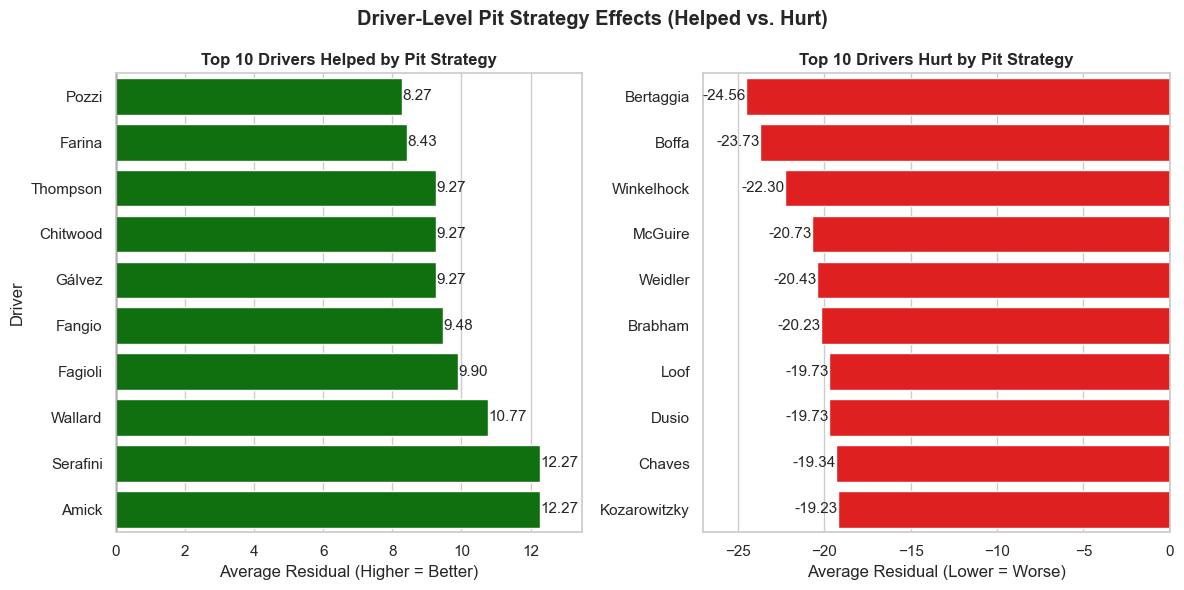

In [29]:
# Prepare top 10 helped and top 10 hurt
top_helped = driver_effects.sort_values("residual", ascending=False).head(10)
top_hurt = driver_effects.sort_values("residual", ascending=True).head(10)

# Combined figure
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=False)

# Left plot: Top 10 Helped
sns.barplot(
    ax=axes[0], 
    x="residual",
    y="surname",
    data=top_helped.sort_values("residual"), 
    palette=["green"] * len(top_helped) # green theme
)

# Set titles and labels
axes[0].set_title("Top 10 Drivers Helped by Pit Strategy", weight='bold')
axes[0].set_xlabel("Average Residual (Higher = Better)")
axes[0].set_ylabel("Driver")
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_xlim(0, top_helped['residual'].max() * 1.1)

# Annotate bars
for i, v in enumerate(top_helped.sort_values("residual")["residual"]):
    axes[0].text(v + 0.005, i, f"{v:.2f}", va='center', fontsize=11)

# Right plot: Top 10 Hurt
sns.barplot(
    ax=axes[1],
    x="residual",
    y="surname",
    data=top_hurt.sort_values("residual"),
    palette=["red"] * len(top_hurt) # red theme
)

# Set titles and labels
axes[1].set_title("Top 10 Drivers Hurt by Pit Strategy", weight='bold')
axes[1].set_xlabel("Average Residual (Lower = Worse)")
axes[1].set_ylabel("")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_xlim(top_hurt['residual'].min() * 1.1, 0)

# Annotate bars
for i, v in enumerate(top_hurt.sort_values("residual")["residual"]):
    axes[1].text(v - 0.005, i, f"{v:.2f}", va='center', ha='right', fontsize=11)

# Final plot title 
plt.suptitle("Driver-Level Pit Strategy Effects (Helped vs. Hurt)", weight='bold')
plt.tight_layout()
plt.show()

For our visualization, we aggregated the residuals by driver and displayed the top 10 most helped and the top 10 most hurt drivers by the pit-stop strategy. The code that follows puts these visualizations into side-by-side bar charts to provide a clear comparison of the strategy’s effect size and direction using the same scale. Overall, the residual plot shows that some drivers regularly finish around 8–12 places better than predicted, while others often finish more than 20 places worse. This further shows that while pit stops can matter in specific cases, races are not generally “won in the pits” across the available race data we have.

### Question 2: When do pit stops generate the highest net position gains (early, mid, late)?

To study whether pit stops in the early, middle, or late stages of a race generate the highest net position gains, we first need to know each driver’s race position immediately before and immediately after a pit stop. Therefore, we merge the `lap_times` table with the `pit_stops` table to create a table that records each driver’s pit position as the position before the pit stop and records the position in the lap after the pit stop as the position after the pit stop. We then subtract the position after the pit stop from the position before the pit stop to compute the gained position of each driver as a result of the pit stop. A positive value in `position_gain` represents a gain in race position, and a negative value in `position_gain` represents a loss in race position. 

Next, we divide the total distance of the race equally into three segments, Early, Mid, and Late, to clarify which stage in the race each pit stop occurs. This allows us to calculate the average position gain at each pit stage. Using the results, we can create a boxplot with a stripplot to visualize the distribution of gains and losses within each stage. 

In [30]:
# Analyze position changes due to pit stops
pit_with_positions = data['pit_stops'].merge(
    data['lap_times'][['raceId','driverId','lap','position']],
    on=['raceId','driverId','lap'],
    how='left'
).rename(columns={'position':'position_after_pit'})

# Get position before pit (lap - 1)
pit_with_positions = pit_with_positions.merge(
    data['lap_times'].assign(lap=lambda x: x.lap+1)[['raceId','driverId','lap','position']],
    on=['raceId','driverId','lap'],
    how='left'
).rename(columns={'position':'position_before_pit'})

# Compute position gain/loss due to pit stop
pit_with_positions['position_gain'] = pit_with_positions['position_before_pit'] - pit_with_positions['position_after_pit']

# Compute pit stage based on lap percentage
race_laps = data['results'].groupby('raceId')['laps'].max().reset_index().rename(columns={'laps':'total_laps'})
pit_with_positions = pit_with_positions.merge(race_laps, on='raceId')
pit_with_positions['pit_pct'] = pit_with_positions['lap'] / pit_with_positions['total_laps']

# Define pit stages
pit_with_positions['pit_stage'] = pd.cut(
    pit_with_positions['pit_pct'],
    bins=[0,0.33,0.66,1],
    labels=['early','mid','late']
)

# Average position gain by pit stage
stage_gain = pit_with_positions.groupby('pit_stage')['position_gain'].mean().reset_index()
print("=== Average Position Gain by Pit Stage ===")
display(stage_gain)

=== Average Position Gain by Pit Stage ===


,pit_stage,position_gain
0,early,-1.022734
1,mid,-0.803612
2,late,-0.527962


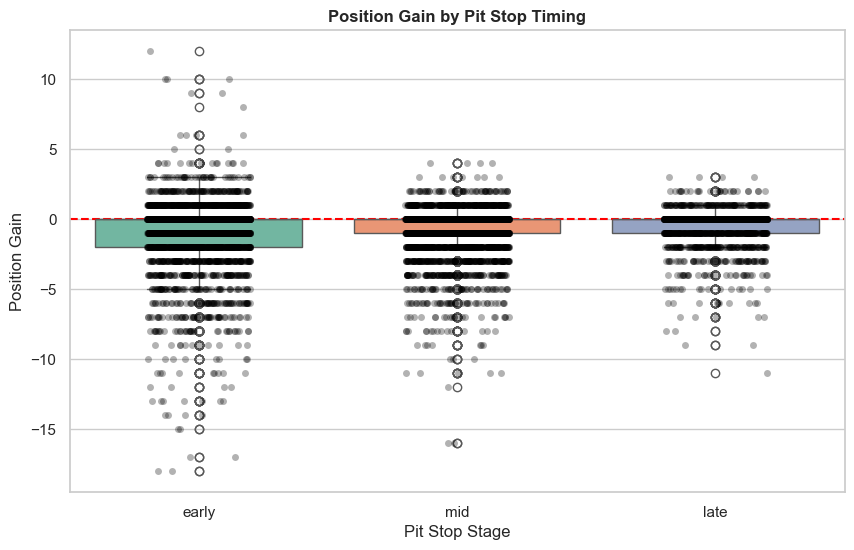

In [31]:
# Visualize position gain by pit stage
plt.figure(figsize=(10,6))
sns.boxplot(data=pit_with_positions, x='pit_stage', y='position_gain', palette='Set2')
sns.stripplot(data=pit_with_positions, x='pit_stage', y='position_gain', color='black', alpha=0.3, jitter=0.2)
plt.title("Position Gain by Pit Stop Timing", weight='bold')
plt.ylabel("Position Gain") # positions before pit - after pit
plt.xlabel("Pit Stop Stage")
plt.axhline(0, color='red', linestyle='--', label='No Gain/Loss')
plt.show()

According to the boxplot, pit stops in all stages tend to result in a small loss in race position, with early stops overall showing the largest losses, while mid-race stops and late stops show approximately equivalent smaller losses. The stripplot also suggests that pit stops tend to result in a small loss across all stages, with early stops showing the most points significantly below zero and late stops showing the least points below zero, clustering more closely around zero. Therefore, the visual suggests that even though neither stage on average would generate a net position gain, late stops generate the smallest average losses.

### Question 3: Which constructors consistently outperform others in pit stop efficiency?

Our goal was to study whether some constructors consistently outperform others in pit stop efficiency, and how much this helps explain overall team success. We start by merging the `pit_stops` with the `results` to make a dataset at the constructor level called `pit_constructor`. so that each pit stop gets the right `constructorId`. This helps us compute a summary of pit stop efficiency measures, such as the average pit stop length `avg_pit_duration` and the total number of stops each team has made. Using these aggregated pit metrics, we then merge in team-level performance variables from results—including each constructor’s average finishing position `avg_finish` and total accumulated points `total_points`. The resulting table summarizes both pit efficiency and competitive performance at the constructor level.

In [32]:
# Constructor-level pit efficiency vs team performance
pit_constructor = data['pit_stops'].merge(
    data['results'][['raceId','driverId','constructorId','positionOrder','points']],
    on=['raceId','driverId']
)

# Aggregate pit efficiency per constructor
constructor_pit_eff = pit_constructor.groupby('constructorId').agg(
    avg_pit_duration=('milliseconds','mean'),
    total_stops=('stop','count')
).reset_index().merge(
    data['constructors'][['constructorId','name']].rename(columns={'name':'constructor'}),
    on='constructorId'
)

# Team performance metrics
team_perf = data['results'].groupby('constructorId').agg(
    avg_finish=('positionOrder','mean'),
    total_points=('points','sum')
).reset_index()

# Merge and analyze correlation
constructor_perf = constructor_pit_eff.merge(team_perf, on='constructorId')
corr = constructor_perf[['avg_pit_duration','avg_finish']].corr().iloc[0,1]
print(f"Correlation between pit duration and finishing position: {corr:.3f}")

Correlation between pit duration and finishing position: -0.363


In [33]:
# Display top/bottom constructors by pit efficiency
print("=== Top 10 Constructors by Pit Efficiency ===")
display(constructor_perf.sort_values('avg_pit_duration').head(10))

# Display constructors by pit efficiency
print("=== Bottom 10 Constructors by Pit Efficiency ===")
display(constructor_perf.sort_values('avg_pit_duration').tail(10))

=== Top 10 Constructors by Pit Efficiency ===


,constructorId,avg_pit_duration,total_stops,constructor,avg_finish,total_points
12,166,24236.194805,77,Virgin,19.000000,0.0
13,205,24444.211765,85,Lotus,17.973684,0.0
16,208,32463.750877,285,Lotus F1,11.311688,706.0
11,164,32677.766667,150,HRT,19.853448,0.0
15,207,33924.618257,241,Caterham,17.464286,0.0
14,206,34396.836910,233,Marussia,17.642202,2.0
3,5,44486.983895,683,Toro Rosso,13.494403,500.0
7,15,44546.524960,621,Sauber,12.901141,557.0
6,10,50845.770115,609,Force India,11.686321,1098.0
2,4,63261.833747,403,Renault,11.168996,1777.0


=== Bottom 10 Constructors by Pit Efficiency ===


,constructorId,avg_pit_duration,total_stops,constructor,avg_finish,total_points
4,6,74682.195506,890,Ferrari,8.364105,9924.27
10,131,75670.788889,900,Mercedes,5.789668,6726.64
0,1,77249.898075,883,McLaren,9.612245,6085.50
17,209,84025.750000,156,Manor Marussia,16.923077,1.00
18,210,102017.145336,461,Haas F1 Team,14.370370,231.00
19,211,104668.644068,118,Racing Point,10.631579,283.00
8,51,150177.350598,251,Alfa Romeo,13.293059,341.00
20,213,206209.518519,189,AlphaTauri,11.663462,276.00
9,117,207027.690476,126,Aston Martin,12.148148,97.00
21,214,230621.220339,118,Alpine F1 Team,9.971429,251.00


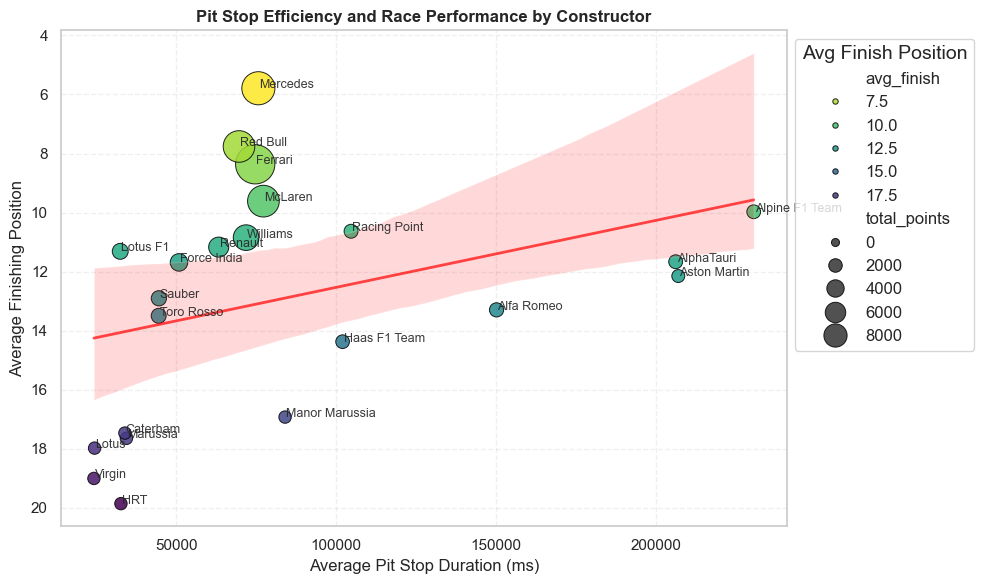

In [34]:
plt.figure(figsize=(10, 6))

# Scatter plot: performance vs pit efficiency
scatter = sns.scatterplot(
    data=constructor_perf,
    x='avg_pit_duration', y='avg_finish',
    size='total_points', sizes=(80, 800),
    hue='avg_finish', # continuous color scale
    palette='viridis_r', alpha=0.85,
    edgecolor='black'
)

# Trend line (OLS)
sns.regplot(
    data=constructor_perf,
    x='avg_pit_duration',
    y='avg_finish',
    scatter=False,
    color='red',
    line_kws={"linewidth": 2, "alpha": 0.7}
)

# Add constructor labels directly to points
for i, row in constructor_perf.iterrows():
    plt.text(
        row['avg_pit_duration'] + 300,
        row['avg_finish'],
        row['constructor'],
        fontsize=9, alpha=0.9
    )

# Titles and labels
plt.title("Pit Stop Efficiency and Race Performance by Constructor", weight='bold')
plt.xlabel("Average Pit Stop Duration (ms)")
plt.ylabel("Average Finishing Position")
plt.legend(title='Avg Finish Position', loc='upper left',
           bbox_to_anchor=(1, 1), markerscale=0.65, 
           fontsize=12, title_fontsize=14) 
plt.gca().invert_yaxis() # Invert y-axis (1st is at the top)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

We first apply this dataset to determine the correlation between pit efficiency and race outcomes. The correlation between `avg_pit_duration` and `avg_finish` is $-0.363$, indicating that faster pit stops are weakly associated with better average finishing positions. We then visualized the relationship between average pit duration and the Top 10 and Bottom 10 teams by pit efficiency. The x-axis shows pit efficiency, and the y-axis shows average finishing position (lower = better). The size of the dots is based on `total_points`. To show the overall direction of the association, an OLS trend line is included. The upward trend line shows that longer pit stops are associated with better race results (noted that the y-axis is inverted, which corresponds to the negative correlation we identified earlier). Teams with the fastest pit stops (HRT, Virgin, and Lotus) tend to have the lowest total points. Yet, teams with longer pit stops (Mercedes, Red Bull, and Ferrari) tend to have higher total points. This shows that successful teams might get better race results for reasons other than how fast they can make pit stops. The correlation of $-0.363$ also backs up this idea. It seems that pit efficiency only explains a small part of the differences. In short, pit stop efficiency only explains a small part of a constructor’s performance compared to other significant factors like car performance, driver strategy, and team resources.

### Discussion

In summary, all three of our analyses show that Formula 1 races are not "won in the pits." First, modeling driver outcomes showed that when grid placement is taken into account, the number and duration of pit stops only have a small effect on a driver's finishing position. Second, examining the timing of pit stops revealed that early, mid, and late stops all tend to result in small net position losses, with late stops losing the least, but none producing average position gains. Finally, at the constructor level, the teams with the fastest pit stops don't get the most points. Instead, teams are getting consistently good results, even if their pit stops are only average or even slower. When considered together, these findings show that pit stop efficiency matters, but not as much as most people think. In reality, factors such as how well the car performs, how skilled the driver is, and how well the strategy is carried out are far more important in determining success in Formula 1.